<a href="https://www.pieriandata.com"><img src="../DATA/Logo.jpg"></a>

# Image Basics Assessment

## Complete the Tasks in bold below. Keep in mind, you may need to run some of these tasks as Python scripts.

----------
#### TASK: Open the *dog_backpack.jpg* image from the DATA folder and display it in the notebook. Make sure to correct for the RGB order.

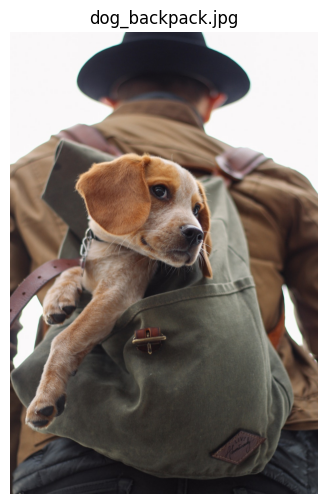

In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

img_path = Path("dog_backpack.jpg")
img = cv2.imread(str(img_path))

if img is None:
    raise FileNotFoundError(f"Could not read image at: {img_path}")

# OpenCV loads BGR, so convert to RGB for correct matplotlib display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("dog_backpack.jpg")
plt.axis("off")
plt.show()


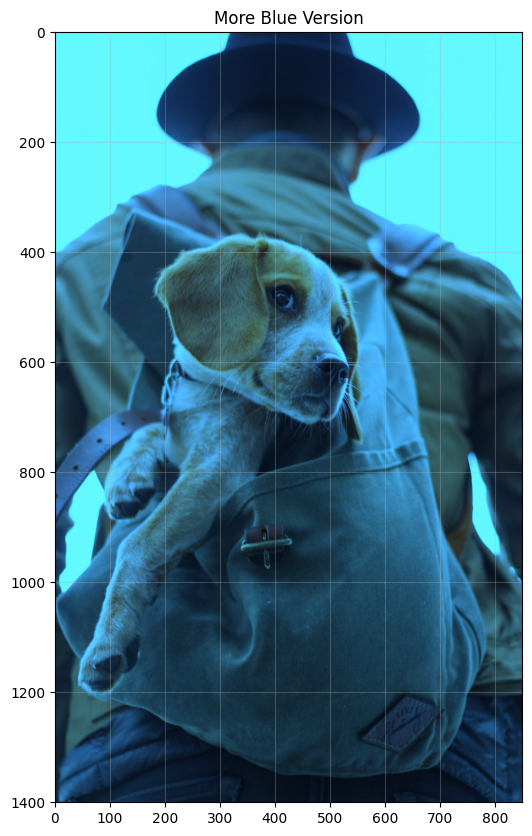

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("dog_backpack.jpg")
if img is None:
    raise FileNotFoundError("Image not found: dog_backpack.jpg")

# Resize to match your requested coordinate range
img = cv2.resize(img, (850, 1400))  # (width, height)

# OpenCV uses BGR channels
b, g, r = cv2.split(img)

# Make image more blue:
# - increase blue channel
# - reduce red channel
b = np.clip(b * 1.5, 0, 255).astype(np.uint8)
r = np.clip(r * 0.4, 0, 255).astype(np.uint8)

blue_stronger = cv2.merge([b, g, r])

# Convert BGR -> RGB for matplotlib display
blue_stronger_rgb = cv2.cvtColor(blue_stronger, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 10))
plt.imshow(blue_stronger_rgb)
plt.title("More Blue Version")

# Coordinate axes
plt.xlim(0, 850)
plt.ylim(1400, 0)  # keep origin at top-left like image coordinates
plt.xticks(np.arange(0, 851, 100))
plt.yticks(np.arange(0, 1401, 200))
plt.grid(True, alpha=0.3)

plt.show()


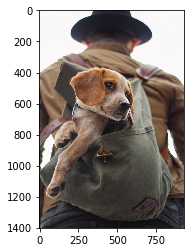

#### TASK: Flip the image upside down and display it in the notebook.

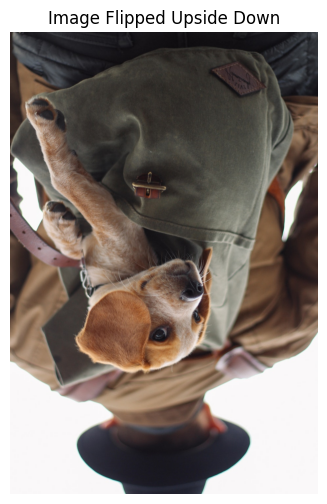

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("dog_backpack.jpg")
if img is None:
    raise FileNotFoundError("Image not found: dog_backpack.jpg")

# Flip the image upside down (flip along x-axis)
flipped_img = cv2.flip(img, 0)  # 0 flips vertically (upside down)

# Convert BGR to RGB for correct display
flipped_img_rgb = cv2.cvtColor(flipped_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(flipped_img_rgb)
plt.title("Image Flipped Upside Down")
plt.axis("off")
plt.show()

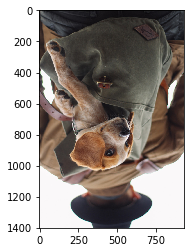

#### TASK: Draw an empty RED rectangle around the dogs face and display the image in the notebook.

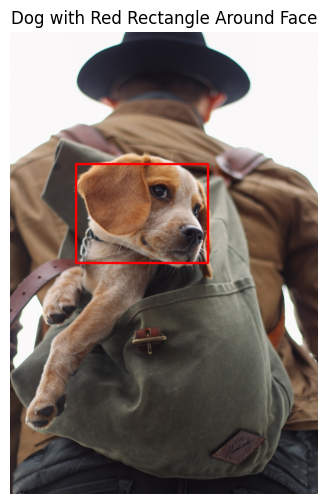

Rectangle centered around the dog's face!


In [24]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("dog_backpack.jpg")
if img is None:
    raise FileNotFoundError("Image not found: dog_backpack.jpg")

# Make a copy to draw on
img_with_rect = img.copy()

# Draw a RED rectangle around the dog's face
# Centered on the dog's face
top_left = (200, 400)      # x, y - top left corner
bottom_right = (600, 700)  # x, y - bottom right corner
color_red = (0, 0, 255)    # BGR format (Red)
thickness = 6

cv2.rectangle(img_with_rect, top_left, bottom_right, color_red, thickness)

# Convert BGR to RGB for display
img_with_rect_rgb = cv2.cvtColor(img_with_rect, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_rect_rgb)
plt.title("Dog with Red Rectangle Around Face")
plt.axis("off")
plt.show()

print("Rectangle centered around the dog's face!")

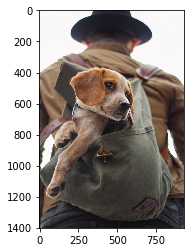

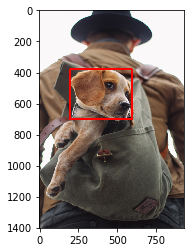

#### TASK: Draw a BLUE TRIANGLE in the middle of the image. The size and angle is up to you, but it should be a triangle (three sides) in any orientation.

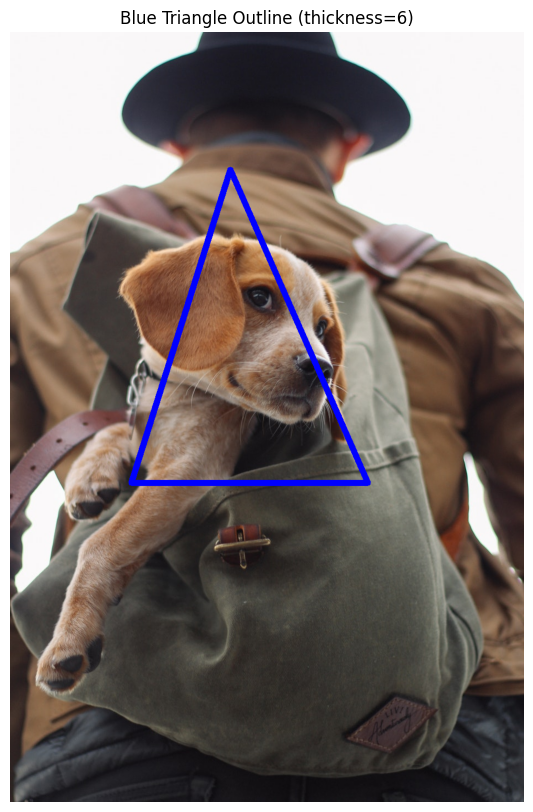

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("dog_backpack.jpg")
if img is None:
    raise FileNotFoundError("Image not found: dog_backpack.jpg")

out = img.copy()

triangle_points = np.array([
    [400, 250],   # top
    [220, 820],   # bottom-left
    [650, 820]    # bottom-right
], dtype=np.int32)

# Not full (outline only), thick = 6
cv2.polylines(out, [triangle_points], isClosed=True, color=(255, 0, 0), thickness=10)  # BGR blue

out_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 10))
plt.imshow(out_rgb)
plt.title("Blue Triangle Outline (thickness=6)")
plt.axis("off")
plt.show()


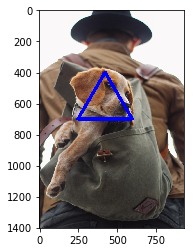

### BONUS TASK. Can you figure our how to fill in this triangle? It requires a different function that we didn't show in the lecture! See if you can use google search to find it.

[CLICK ME FOR A DIRECT LINK TO THE HINT](https://docs.opencv.org/3.0-beta/modules/imgproc/doc/drawing_functions.html#fillpoly)

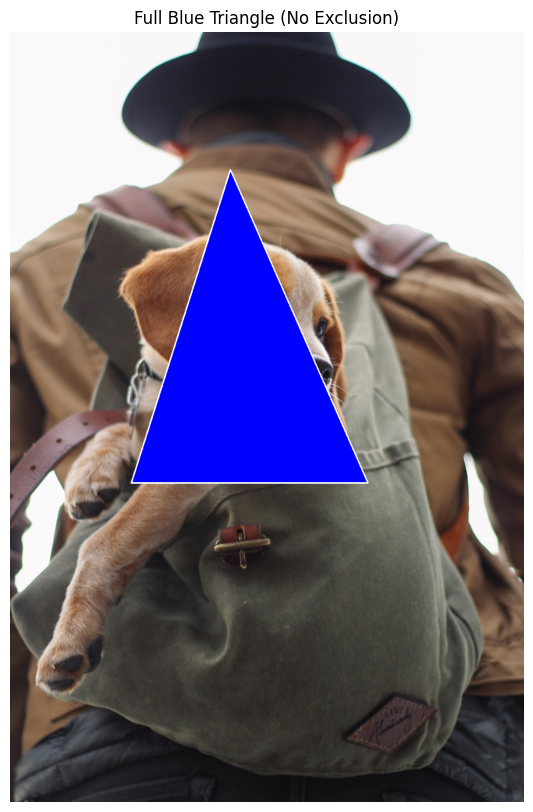

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("dog_backpack.jpg")
if img is None:
    raise FileNotFoundError("Image not found: dog_backpack.jpg")

out = img.copy()

# Triangle points (adjust if needed)
triangle_points = np.array([
    [400, 250],   # top
    [220, 820],   # bottom-left
    [650, 820]    # bottom-right
], dtype=np.int32)

# Full blue filled triangle (no exclusion)
cv2.fillPoly(out, [triangle_points], color=(255, 0, 0))  # BGR blue

# Optional white border
cv2.polylines(out, [triangle_points], isClosed=True, color=(255, 255, 255), thickness=2)

# Show
out_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 10))
plt.imshow(out_rgb)
plt.title("Full Blue Triangle (No Exclusion)")
plt.axis("off")
plt.show()


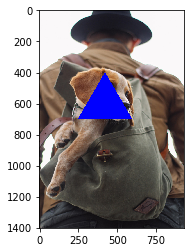

#### TASK: (NOTE: YOU WILL NEED TO RUN THIS AS A SCRIPT). Create a script that opens the picture and allows you to draw empty red circles whever you click the RIGHT MOUSE BUTTON DOWN.

In [32]:
import cv2
import numpy as np

# Load the image
img = cv2.imread("dog_backpack.jpg")
if img is None:
    raise FileNotFoundError("Image not found: dog_backpack.jpg")

# Create a copy to draw on
img_copy = img.copy()

# Mouse callback function
def mouse_callback(event, x, y, flags, param):
    global img_copy
    
    # cv2.EVENT_RBUTTONDOWN is the right mouse button down event
    if event == cv2.EVENT_RBUTTONDOWN:
        # Draw a red circle at the clicked position
        color_red = (0, 0, 255)  # BGR format (Red)
        radius = 20
        thickness = 2  # -1 would fill the circle, use 2 for outline
        
        cv2.circle(img_copy, (x, y), radius, color_red, thickness)
        
        # Update the display
        cv2.imshow("Draw Circles on Right Click", img_copy)

# Create the window
cv2.namedWindow("Draw Circles on Right Click")

# Set the mouse callback function
cv2.setMouseCallback("Draw Circles on Right Click", mouse_callback)

# Display the image
cv2.imshow("Draw Circles on Right Click", img_copy)

# Wait until the user presses 'q' to quit
while True:
    key = cv2.waitKey(0)
    if key == ord('q'):
        break

# Clean up
cv2.destroyAllWindows()
print("Closed the window. Script complete!")


KeyboardInterrupt: 